## Requirements

In [2]:
%pip install wfdb --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.3 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


## Import and Configuration

In [16]:
# Standard Library
import os
import random

# Data Manipulation & Math
import numpy as np
import pandas as pd
from tqdm import tqdm

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Signal Processing & Domain Specific
import wfdb
from scipy.signal import butter, filtfilt

# Scikit-Learn (Machine Learning)
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score, 
    confusion_matrix, f1_score, roc_auc_score, classification_report
)

# TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import Sequential, backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, SpatialDropout1D, Add,
    Activation, BatchNormalization, GlobalAveragePooling1D, 
    Concatenate, Lambda, Reshape, Bidirectional, LSTM
)

# Configuration & Constants
INPUT_DIR = "/kaggle/input/"
OUTPUT_DIR = "/kaggle/working/"
DATASET_PATH = os.path.join(INPUT_DIR, "datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1")
META_FILE_PTB = os.path.join(DATASET_PATH, "ptbxl_database.csv")
META_FILE_SCP = os.path.join(DATASET_PATH, "scp_statements.csv")

# Research Grade Parameters
SEED = 42
SAMPLE_RATE = 500
AGGREGATE_CLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
NUM_CLASSES = len(AGGREGATE_CLASSES)
MAX_RECORDS = 10000

# Set Seeds
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Helper Functions

In [21]:
def safe_eval_scp(scp_code):
    """
    Description: Safely converts string-formatted SCP dictionaries into Python dictionary objects.
    Input: str or dict
    Output: dict
    """
    try: 
        return eval(scp_code) if isinstance(scp_code, str) else scp_code
    except: 
        return {}

def apply_bandpass_filter(signal, fs, lowcut=0.5, highcut=45.0, order=2):
    """
    Description: Applies a Butterworth bandpass filter to remove baseline wander and noise.
    Input: numpy array, float, float, float, int
    Output: numpy array
    """
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='bandpass')
    return filtfilt(b, a, signal, axis=0)

def ensure_len(signal, target_len):
    """
    Description: Pads or truncates the signal to reach a consistent target length.
    Input: numpy array, int
    Output: numpy array
    """
    current_len = len(signal)
    if current_len > target_len:
        return signal[:target_len]
    elif current_len < target_len:
        pad_len = target_len - current_len
        return np.pad(signal, ((0, pad_len), (0, 0)), mode='constant')
    return signal

def normalize_dataset(X):
    """
    Description: Applies Lead-wise Z-score Normalization (Research Grade).
                 Standardizes each lead for every patient individually.
    Input: numpy array (records, samples, leads)
    Output: numpy array (records, samples, leads)
    """
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True)
    std[std == 0] = 1.0
    return (X - mean) / std

# def find_optimal_threshold(y_true, y_prob):
#     """
#     Description: Searches for the threshold that maximizes the F1-Score 
#                  for the Binary Screening task on the validation set.
#     Input: numpy array (N, 5), numpy array (N, 5)
#     Output: float (optimal threshold)
#     """
#     # Create True Binary Ground Truth (0=NORM only, 1=Any Pathology)
#     y_true_bin = np.array([0 if (row[0] == 1 and np.sum(row) == 1) else 1 for row in y_true])
#     # Model's max suspicion of ANY pathology
#     path_probs = np.max(y_prob[:, 1:], axis=1) 
    
#     thresholds = np.linspace(0.01, 0.9, 90)
#     f1_scores = [f1_score(y_true_bin, (path_probs > t).astype(int), zero_division=0) for t in thresholds]
    
#     opt_t = thresholds[np.argmax(f1_scores)]
#     print(f"Optimal Threshold Found: {opt_t:.3f} (Val F1: {max(f1_scores):.4f})")
#     return opt_t

def find_optimal_thresholds(y_true, y_prob, class_names=AGGREGATE_CLASSES):
    """
    Description: Individually optimizes the F1-Score for each of the 5 classes.
    Output: List of 5 optimal thresholds.
    """
    opt_thresholds = []
    thresholds = np.linspace(0.05, 0.8, 100)

    for i in range(len(class_names)):
        f1_scores = [f1_score(y_true[:, i], (y_prob[:, i] >= t).astype(int), zero_division=0) 
                     for t in thresholds]
        
        best_idx = np.argmax(f1_scores)
        best_t = thresholds[best_idx]
        best_f1 = f1_scores[best_idx]
        
        opt_thresholds.append(best_t)
        print(f"Class: {class_names[i]:<6} | Best T: {best_t:.3f} | F1: {best_f1:.4f}")
        
    return opt_thresholds

def focal_loss(gamma=2., alpha=0.75):
    """
    Binary Focal Loss for multi-label classification.
    alpha: balancing factor to handle class imbalance.
    gamma: focusing parameter to focus on hard-to-classify examples.
    """
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        # Clip predictions to prevent log(0)
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        
        # Calculate cross entropy
        cross_entropy = -y_true * K.log(y_pred)
        
        # Calculate focal weight
        # (1 - p)^gamma for actual positives, p^gamma for actual negatives
        weight = y_true * K.pow(1 - y_pred, gamma) + (1 - y_true) * K.pow(y_pred, gamma)
        
        # Apply alpha and weights
        loss = alpha * weight * cross_entropy
        
        return K.mean(K.sum(loss, axis=-1))
    return focal_loss_fixed

def print_result(res):
    """
    Description: Formats and prints classification performance metrics to the console.
    Input: dict [model, accuracy, precision, recall, f1 score]
    """
    print(f"\nModel: {res['model']}")
    print(f"Accuracy: {res['accuracy']:.2%}")
    print(f"Precision: {res['precision']:.2%}")
    print(f"Recall: {res['recall']:.2%}")
    print(f"F1 Score: {res['f1 score']:.2%}")

## Load Metadata

In [5]:
def load_metadata(max_records=MAX_RECORDS):
    """
    Description: Loads PTB-XL CSV files and applies multi-label vectorization 
                 while preserving the research-standard strat_fold.
    Input: int
    Output: pandas DataFrame
    """
    # Load raw dataframes
    ptb_df = pd.read_csv(META_FILE_PTB, index_col='ecg_id')
    scp_df = pd.read_csv(META_FILE_SCP, index_col=0)

    # Convert scp_codes from string to dict
    ptb_df["scp_codes"] = ptb_df["scp_codes"].apply(safe_eval_scp)
    
    # Filter for records with valid filenames (using 100Hz version)
    ptb_df = ptb_df[ptb_df["filename_lr"].notna()] 

    # Build the Dictionary Map (SCP Code -> Diagnostic Class)
    scp_df = scp_df[scp_df["diagnostic_class"].notna()]
    diag_map = scp_df["diagnostic_class"].to_dict()

    # Define Multi-label Vectorization Function
    def get_multilabel_vector(scp_dict):
        vec = np.zeros(len(AGGREGATE_CLASSES), dtype=np.float32)
        for code in scp_dict.keys():
            if code in diag_map:
                cls = diag_map[code]
                if cls in AGGREGATE_CLASSES:
                    vec[AGGREGATE_CLASSES.index(cls)] = 1.0
        return vec

    # Apply Multi-label Vectors
    ptb_df["label_vector"] = ptb_df["scp_codes"].apply(get_multilabel_vector)
    
    # Create Binary Label for Screening (0=Only NORM, 1=Any Pathology)
    ptb_df["label_binary"] = ptb_df["label_vector"].apply(
        lambda v: 0 if (v[0] == 1 and np.sum(v) == 1) else 1
    )

    # Filter out records that don't belong to any of the 5 superclasses
    ptb_df = ptb_df[ptb_df["label_vector"].apply(lambda v: np.sum(v) > 0)]

    # Optional Sampling
    if max_records:
        ptb_df = ptb_df.sample(n=min(max_records, len(ptb_df)), random_state=SEED)

    return ptb_df.reset_index()

ptb_df = load_metadata()
print("Total valid records: ", {len(ptb_df)})
print("\nBinary Counts (0=Normal, 1=Abnormal):")
print(ptb_df["label_binary"].value_counts())
ptb_df[["ecg_id", "scp_codes", "label_vector", "label_binary"]]

Total valid records:  {10000}

Binary Counts (0=Normal, 1=Abnormal):
label_binary
1    5744
0    4256
Name: count, dtype: int64


,ecg_id,scp_codes,label_vector,label_binary
0,3414,"{'NORM': 50.0, 'SR': 0.0}","[1.0, 0.0, 0.0, 0.0, 0.0]",0
1,4761,"{'NST_': 100.0, 'AFIB': 100.0}","[0.0, 0.0, 1.0, 0.0, 0.0]",1
2,2564,"{'NDT': 100.0, 'SR': 0.0}","[0.0, 0.0, 1.0, 0.0, 0.0]",1
3,13929,"{'NORM': 100.0, 'SR': 0.0}","[1.0, 0.0, 0.0, 0.0, 0.0]",0
4,13339,"{'WPW': 100.0, 'SR': 0.0}","[0.0, 0.0, 0.0, 1.0, 0.0]",1
...,...,...,...,...
9995,7013,"{'IMI': 15.0, 'ABQRS': 0.0, 'SR': 0.0}","[0.0, 1.0, 0.0, 0.0, 0.0]",1
9996,1055,"{'ASMI': 15.0, 'LAFB': 100.0, 'STACH': 0.0}","[0.0, 1.0, 0.0, 1.0, 0.0]",1
9997,12437,"{'NDT': 100.0, 'LVH': 15.0, 'LOWT': 0.0, 'STD_...","[0.0, 0.0, 1.0, 0.0, 1.0]",1
9998,20858,"{'IMI': 100.0, 'ABQRS': 0.0, 'SR': 0.0}","[0.0, 1.0, 0.0, 0.0, 0.0]",1


## Load One Signal and Smoke Test

Showing first 1 records (12-Lead view)...


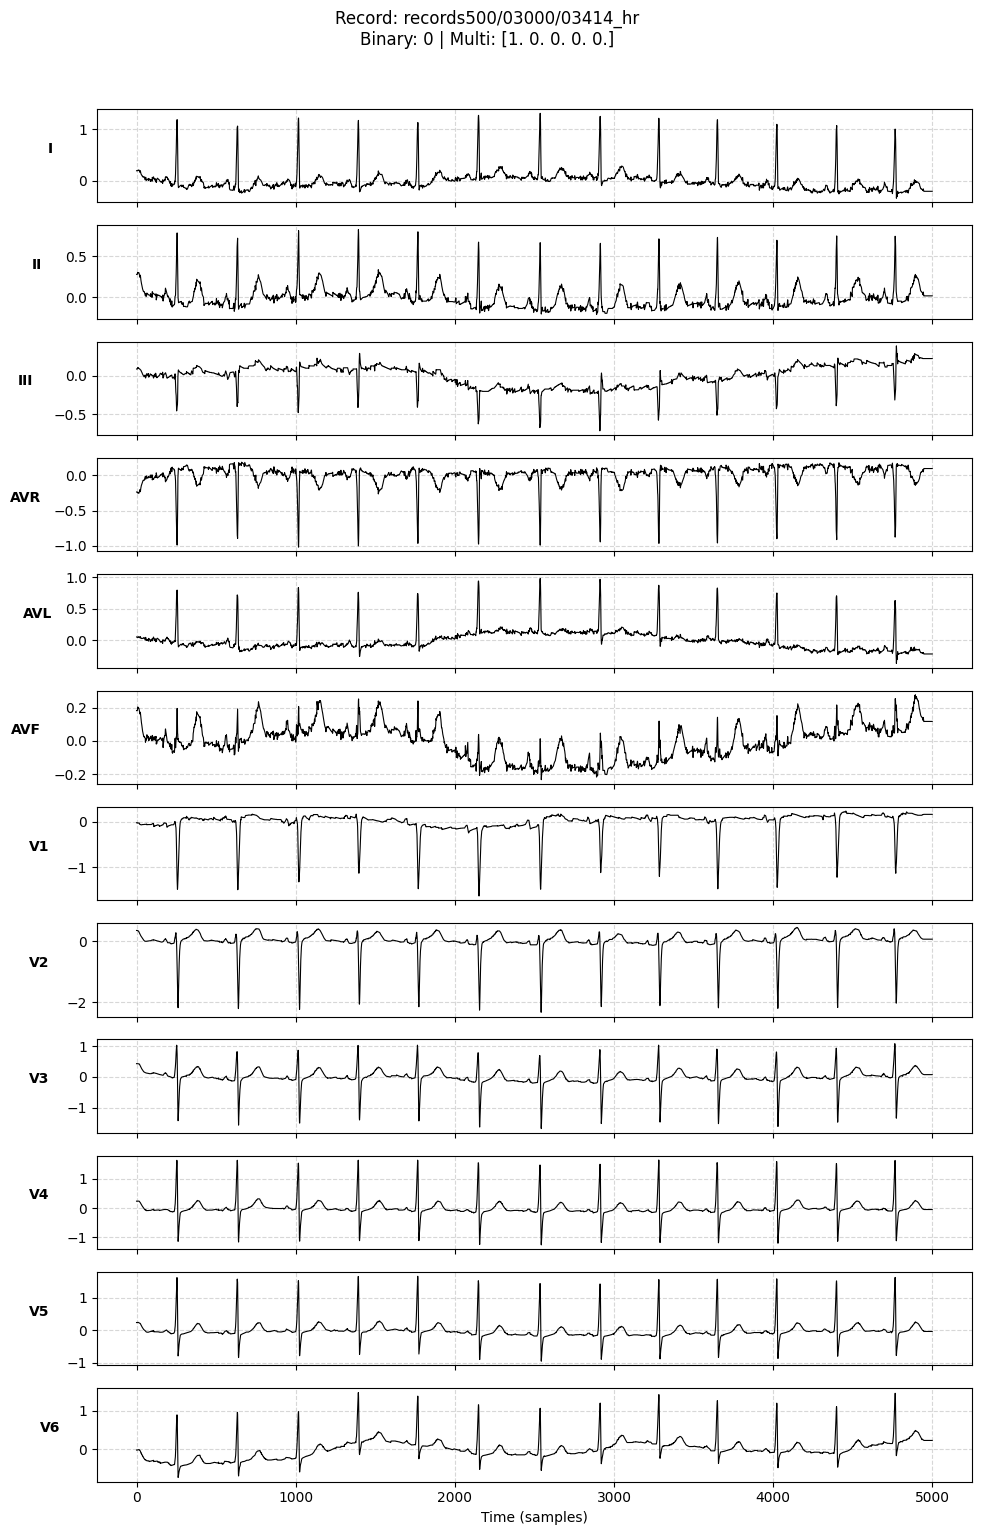

In [6]:
def load_signal_single(filename, base_path=DATASET_PATH):
    """
    Description: Loads a single 12-lead ECG signal using the wfdb library.
    Input: str, str
    Output: numpy array (samples, 12)
    """
    try:
        path = os.path.join(base_path, filename)
        signal, _ = wfdb.rdsamp(path)
        return signal.astype(np.float32)
    except:
        return None

def smoke_test(df, count=1):
    """
    Description: Visualizes the first N records of the provided DataFrame in a 
                 stacked 12-lead anatomical view to verify data integrity.
    Input: pandas DataFrame [filename_lr/filename_hr, label_binary, label_multiclass, ...], int
    """
    print(f"Showing first {count} records (12-Lead view)...")

    lead_names = ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    for row in df.itertuples():
        file = "filename_lr" if SAMPLE_RATE == 100 else "filename_hr"
        sig = load_signal_single(getattr(row, file))
        if sig is None:
            continue

        # Ensure length
        sig = ensure_len(sig, SAMPLE_RATE * 10)

        # Plot all 12 leads stacked
        fig, axes = plt.subplots(12, 1, figsize=(10, 15), sharex=True)

        for i in range(12):
            ax = axes[i]
            ax.plot(sig[:, i], color='black', linewidth=0.8)
            ax.set_ylabel(lead_names[i], rotation=0, labelpad=20, fontsize=10, fontweight='bold')
            ax.grid(True, linestyle='--', alpha=0.5)
            if i < 11:
                ax.tick_params(labelbottom=False)

        plt.suptitle(f"Record: {getattr(row, file)}\nBinary: {row.label_binary} | Multi: {row.label_vector}", y=1.02)
        plt.xlabel("Time (samples)")
        plt.tight_layout()
        plt.show()

        count -= 1
        if count == 0:
            return

smoke_test(df=ptb_df)

## Build and Split Dataset

In [7]:
def build_dataset(df):
    """
    Description: Iteratively loads signals and aggregates data with fold 
                 assignments using selected frequency filenames.
    Input: pandas DataFrame
    Output: tuple (X, y_bin, y_vec, folds)
    """
    X, y_bin, y_vec, folds = [], [], [], []
    file = "filename_lr" if SAMPLE_RATE == 100 else "filename_hr"

    for row in tqdm(df.itertuples(), total=len(df), desc=f"Loading {SAMPLE_RATE}Hz ECGs"):
        sig = load_signal_single(getattr(row, file)) 
        if sig is None: continue
            
        # Apply Clinical Bandpass Filter
        sig = apply_bandpass_filter(sig, fs=float(SAMPLE_RATE))
        
        # Standardize length to 10 seconds (100 * 10 or 500 * 10)
        sig = ensure_len(sig, SAMPLE_RATE * 10) 

        X.append(sig)
        y_bin.append(row.label_binary)
        y_vec.append(row.label_vector)
        folds.append(row.strat_fold)

    # Stack to create 3D Array: (records, samples, 12)
    X = np.stack(X)
    y_bin = np.array(y_bin)
    y_vec = np.stack(y_vec)
    folds = np.array(folds)
    
    return X, y_bin, y_vec, folds

# Build
X, y_bin, y_vec, folds = build_dataset(ptb_df)

# Normalization
X = normalize_dataset(X)

# Split (1-8: Train, 9: Val, 10: Test)
train_idx = np.where(folds <= 8)[0]
val_idx   = np.where(folds == 9)[0]
test_idx  = np.where(folds == 10)[0]

X_train, y_train = X[train_idx], y_vec[train_idx]
X_val,   y_val   = X[val_idx],   y_vec[val_idx]
X_test,  y_test  = X[test_idx],  y_vec[test_idx]

y_bin_test = y_bin[test_idx]

# Display Shapes 
print("\n--- Final Research Dataset Built ---")
print(f"Total Records: {len(X)}")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}  | y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}  | y_test shape:  {y_test.shape}")

Loading 500Hz ECGs: 100%|██████████| 10000/10000 [03:20<00:00, 49.91it/s]



--- Final Research Dataset Built ---
Total Records: 10000
X_train shape: (7978, 5000, 12) | y_train shape: (7978, 5)
X_val shape:   (1027, 5000, 12)  | y_val shape:   (1027, 5)
X_test shape:  (995, 5000, 12)  | y_test shape:  (995, 5)


## Universal Evaluator

In [18]:
def evaluate_model(model_name, y_true, y_pred_probs, thresholds, class_names=AGGREGATE_CLASSES):
    """
    Comprehensive evaluation for multi-label ECG classification.
    y_true: Ground truth binary matrix (Samples, Classes)
    y_pred_probs: Model output probabilities (Samples, Classes)
    thresholds: Scalar or list of thresholds for binary classification
    """    
    # Apply threshold to get binary predictions for F1 and Confusion Matrix
    y_pred_bin = np.zeros_like(y_pred_probs)
    for i in range(len(class_names)):
        y_pred_bin[:, i] = (y_pred_probs[:, i] >= thresholds[i]).astype(int)

    # --- SECTION 1: METRICS SUMMARY TABLE ---
    metrics_data = []
    for i in range(len(class_names)):
        c_auc = roc_auc_score(y_true[:, i], y_pred_probs[:, i])
        c_f1 = f1_score(y_true[:, i], y_pred_bin[:, i])
        metrics_data.append({"Class": class_names[i], "AUC-ROC": c_auc, "F1-Score": c_f1})
    
    # Calculate Macro Averages
    macro_auc = roc_auc_score(y_true, y_pred_probs, average='macro')
    macro_f1 = f1_score(y_true, y_pred_bin, average='macro')
    
    df_metrics = pd.DataFrame(metrics_data)
    # Add final summary row
    summary_row = pd.DataFrame([{"Class": "MACRO AVERAGE", "AUC-ROC": macro_auc, "F1-Score": macro_f1}])
    df_metrics = pd.concat([df_metrics, summary_row], ignore_index=True)
    
    print(f"\n{'='*40}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*40}")
    print(df_metrics.to_string(index=False))
    print("\n")

    # --- SECTION 2: 5-CLASS CONFUSION MATRIX HEATMAPS ---
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    for i in range(len(class_names)):
        cm = confusion_matrix(y_true[:, i], y_pred_bin[:, i])
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
        axes[i].set_title(f'CM: {class_names[i]}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # --- SECTION 3: MULTI-LINE ROC PLOT WITH MACRO ROC ---
    plt.figure(figsize=(10, 7))
    
    # Calculate and plot per-class ROC
    fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
    for i in range(len(class_names)):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])
        plt.plot(fpr_dict[i], tpr_dict[i], lw=1.5, label=f'ROC {class_names[i]} (area = {roc_auc_dict[i]:.3f})')

    # Calculate Macro-average ROC (mean of all FPR/TPR)
    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(len(class_names))]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(class_names)):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= len(class_names)
    
    plt.plot(all_fpr, mean_tpr, label=f'MACRO-AVERAGE ROC (area = {macro_auc:.3f})', color='black', linestyle=':', linewidth=4)
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) - Multi-Class')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    # --- SECTION 4: MULTI-LINE PR PLOT WITH MACRO PR ---
    plt.figure(figsize=(10, 7))
    
    precision_dict, recall_dict, ap_dict = {}, {}, {}
    for i in range(len(class_names)):
        precision_dict[i], recall_dict[i], _ = precision_recall_curve(y_true[:, i], y_pred_probs[:, i])
        ap_dict[i] = average_precision_score(y_true[:, i], y_pred_probs[:, i])
        plt.plot(recall_dict[i], precision_dict[i], lw=1.5, label=f'PR {class_names[i]} (AP = {ap_dict[i]:.3f})')

    # Calculate Macro-average Precision
    # We use micro-averaging for the visual summary curve of PR in multi-label
    macro_ap = average_precision_score(y_true, y_pred_probs, average="macro")
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curves (Macro AP = {macro_ap:.3f})')
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)
    plt.show()

## CNN Model Building and Training (Binary Classification)

In [24]:
# Configuration
INPUT_SHAPE = (SAMPLE_RATE * 10, 12)
EPOCHS = 50
BATCH_SIZE = 32

# Define CNN Architecture
def build_cnn(input_shape=INPUT_SHAPE):
    """
    Description: Constructs a 1D CNN with hierarchical blocks for multi-label 
                 diagnostic classification using Sigmoid output and Macro-AUC.
    Input: tuple (samples, leads)
    Output: keras.Model
    """
    model = Sequential()
    model.add(Input(shape=input_shape))                              # Shape: (32, 1000, 12)

    # Block 1: Low-level features
    model.add(Conv1D(filters=32, kernel_size=32, strides=2, padding='same'))    # Shape: (32, 500, 32)
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    # Block 2: Mid-level features
    model.add(Conv1D(filters=64, kernel_size=15, strides=2, padding='same'))    # Shape: (32, 250, 64)
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    # Block 3: High-level features
    model.add(Conv1D(filters=128, kernel_size=11, padding='same'))   # Shape: (32, 250, 128)
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    # Classifier Head
    model.add(GlobalAveragePooling1D())                              # Shape: (32, 128)
    model.add(Dense(128, activation='relu'))                         # Shape: (32, 128)
    model.add(Dropout(0.5))
    
    # Multi-label Output: 5 nodes with independent probabilities
    model.add(Dense(NUM_CLASSES, activation='sigmoid'))              # Shape: (32, 5)

    # Compile with Research Gold Standard (Macro-AUC)
    model.compile(
        optimizer=Adam(learning_rate=0.001), 
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True)]
    )
    return model

# Build the model
print(f"\n{'='*40}")
print("BUILDING RESEARCH CNN")
print(f"{'='*40}")
cnn = build_cnn()
cnn.summary()

# Train using the Splits (Folds 1-8 for train, 9 for val)
callbacks_cnn = [
    EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=0.00001, verbose=1)
]

history_cnn = cnn.fit(
    X_train, y_train,        # Folds 1-8
    validation_data=(X_val, y_val), # Fold 9
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_cnn,
    verbose=1
)

# Save the model
cnn.save(os.path.join(OUTPUT_DIR, 'cnn_model.keras'))


BUILDING RESEARCH CNN


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 2500, 32)       │        12,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 2500, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 2500, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 1250, 64)       │        30,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1250, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 1250, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 1250, 128)      │        90,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 1250, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 1250, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,397 (591.39 KB)

 Trainable params: 150,949 (589.64 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - auc: 0.7745 - loss: 0.4416 - val_auc: 0.8639 - val_loss: 0.4218 - learning_rate: 0.0010
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - auc: 0.8580 - loss: 0.3506 - val_auc: 0.8735 - val_loss: 0.4201 - learning_rate: 0.0010
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - auc: 0.8690 - loss: 0.3329 - val_auc: 0.8754 - val_loss: 0.4295 - learning_rate: 0.0010
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - auc: 0.8780 - loss: 0.3230 - val_auc: 0.8851 - val_loss: 0.3863 - learning_rate: 0.0010
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - auc: 0.8854 - loss: 0.3134 - val_auc: 0.8859 - val_loss: 0.3283 - learning_rate: 0.0010
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - auc: 0.8872 - loss: 0.3113 - val_auc: 0.8845 - val_loss: 0.3559 - learning_rate: 0.0010
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - auc: 0.8937 - loss: 0.3023 - val_auc: 0.8931 - val_loss: 0.3740 - learning_rate: 0.001

##  CNN Model Evaluation (Binary Classification)

Generating Probabilities...

Tuning threshold on Validation Set...
Class: NORM   | Best T: 0.383 | F1: 0.8426
Class: MI     | Best T: 0.368 | F1: 0.7121
Class: STTC   | Best T: 0.285 | F1: 0.7414
Class: CD     | Best T: 0.429 | F1: 0.7898
Class: HYP    | Best T: 0.315 | F1: 0.4960

Performing Final Evaluation on Test Set (Fold 10)...

EVALUATION: 1D CNN
        Class  AUC-ROC  F1-Score
         NORM 0.940922  0.850052
           MI 0.917746  0.721311
         STTC 0.928809  0.737240
           CD 0.913630  0.745283
          HYP 0.849493  0.470085
MACRO AVERAGE 0.910120  0.704794




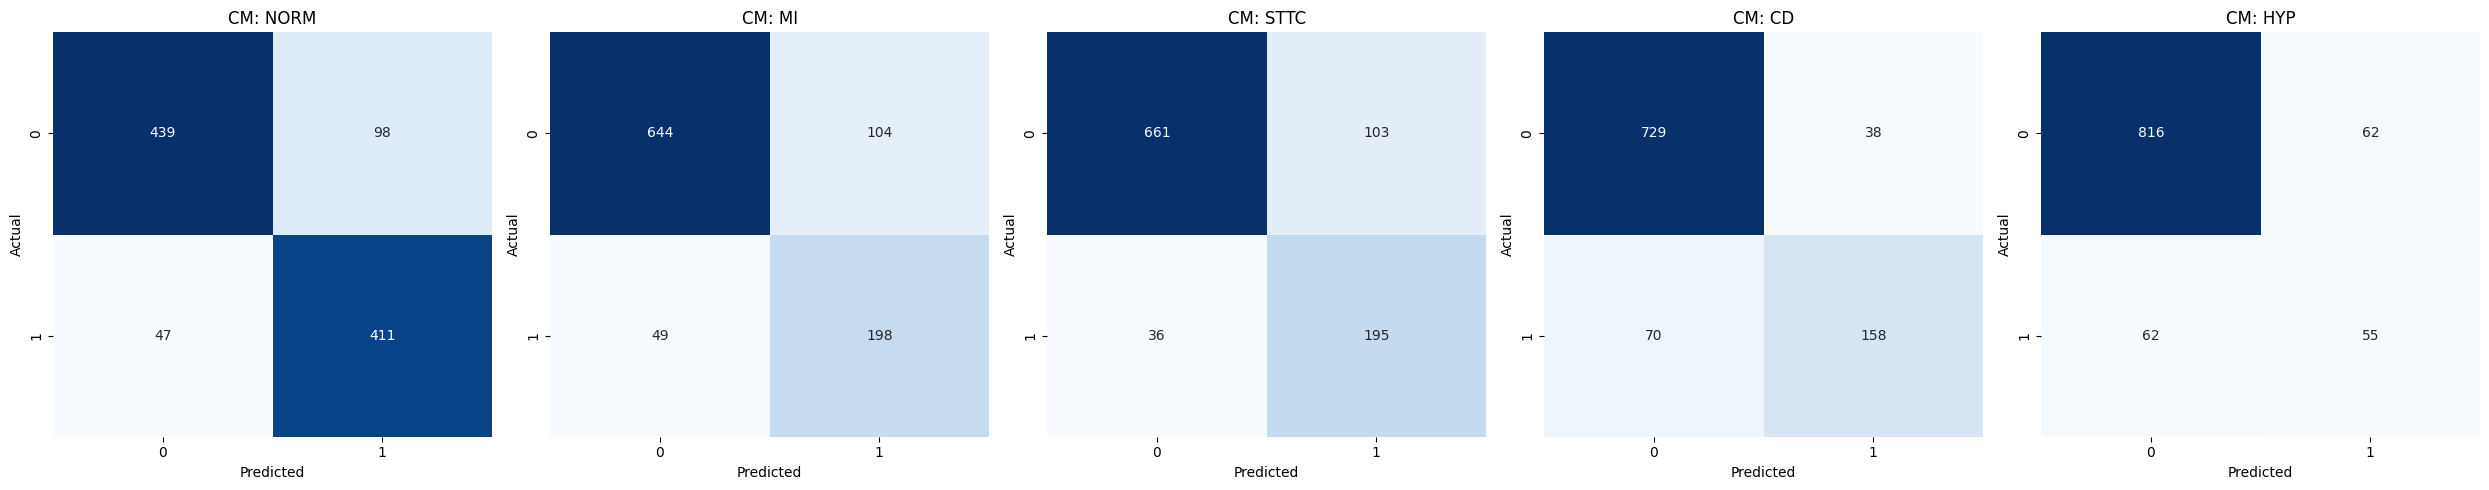

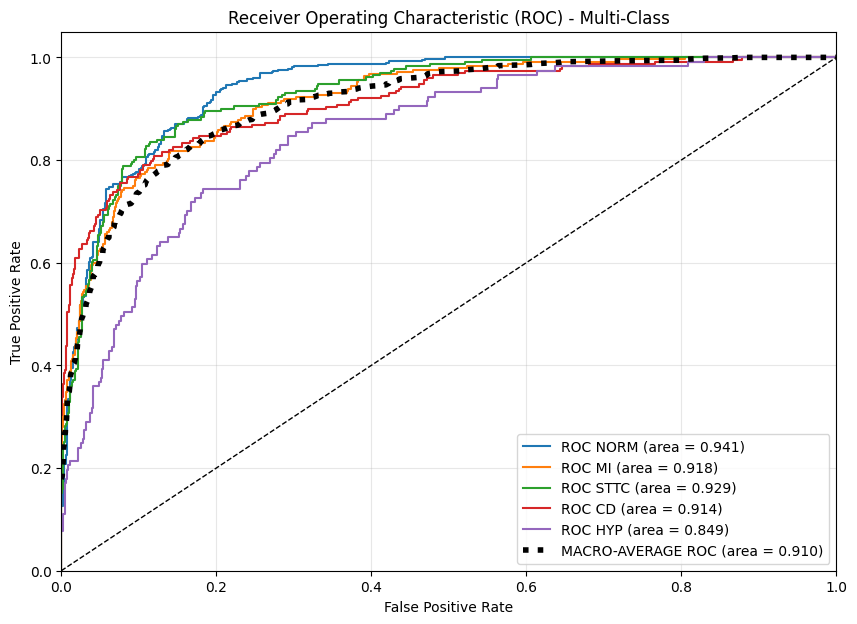

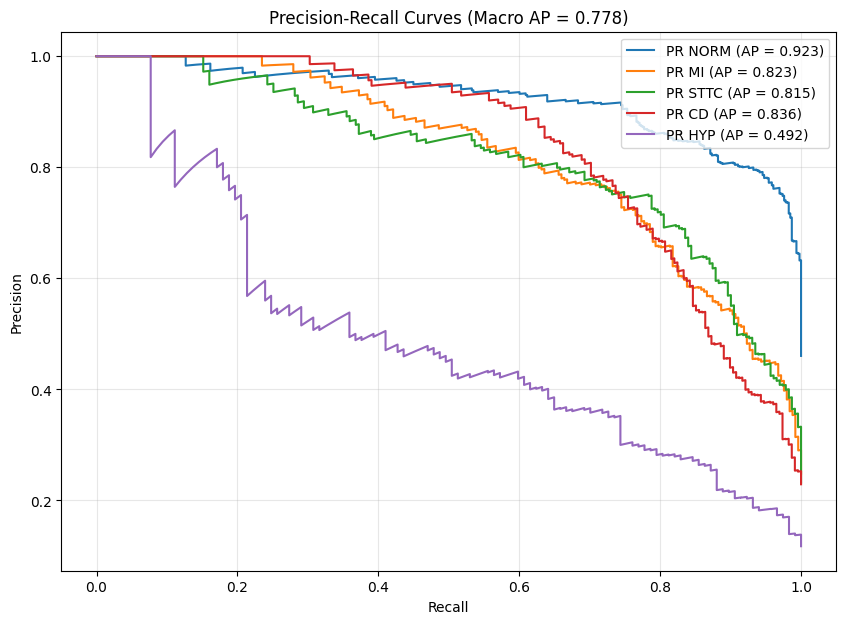

In [25]:
# Predict on Validation and Test Sets
print("Generating Probabilities...")
y_prob_val = cnn.predict(X_val, verbose=0)
y_prob_test = cnn.predict(X_test, verbose=0)

# Find Optimal Threshold on Validation Set (Fold 9)
print("\nTuning threshold on Validation Set...")
opt_threshold = find_optimal_thresholds(y_val, y_prob_val)

# Evaluate on Test Set (Fold 10) using tuned threshold
print("\nPerforming Final Evaluation on Test Set (Fold 10)...")
res_cnn = evaluate_model("1D CNN", y_test, y_prob_test, opt_threshold)

## AG-ResNET Model Building and Training (Binary Classification)

In [ ]:
# Configuration
INPUT_SHAPE = (SAMPLE_RATE * 10, 12)
NUM_CLASSES = 5
NUM_BLOCKS = 3
FILTERS_START = 32

LEARNING_RATE = 0.0005 
BATCH_SIZE = 16
EPOCHS = 50

# Define Residual Block Architecture
def residual_block(x, filters, kernel_size=10, stride=1):
    """
    Description: Implements a standard 1D Residual bottleneck with 'swish' activation and 
                 spatial dropout; includes a 1x1 convolution shortcut if dimensions change.
    Input: tensorflow.Tensor [time, channels], int, int, int
    Output: tensorflow.Tensor [time/stride, filters]
    """

    shortcut = x

    # Path A
    x = Conv1D(filters, kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = SpatialDropout1D(0.2)(x)

    x = Conv1D(filters, kernel_size, strides=1, padding='same')(x)
    x = BatchNormalization()(x)

    # Path B
    if x.shape[-1] != shortcut.shape[-1] or stride != 1:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('swish')(x)
    return x

# Define AG ResNet Architecture
def build_ag_resnet(input_shape=INPUT_SHAPE):
    """
    Description: Constructs the Anatomically Grouped ResNet by splitting 12 leads into 
                 5 regional branches (Septal, Anterior, Lateral, Inferior, Posterior) before 
                 fusing them for classification.
    Note: samples = signal duration * frequency
    Input: tuple (samples, leads)
    Output: keras.src.models.model.Model
    """
    # --- BLOCK 1: INPUT & TRIAGE ---
    input_layer = Input(shape=input_shape, name="ecg_input") # Shape: (16, 5000, 12)
 
    septal = Lambda(lambda x: __import__('tensorflow').gather(x, [6, 7], axis=2), name="Septal")(input_layer)            # Shape: (16, 5000, 2)
    anterior = Lambda(lambda x: __import__('tensorflow').gather(x, [8, 9], axis=2), name="Anterior")(input_layer)        # Shape: (16, 5000, 2)
    lateral = Lambda(lambda x: __import__('tensorflow').gather(x, [0, 4, 10, 11], axis=2), name="Lateral")(input_layer)  # Shape: (16, 5000, 4)
    inferior = Lambda(lambda x: __import__('tensorflow').gather(x, [1, 2, 5], axis=2), name="Inferior")(input_layer)     # Shape: (16, 5000, 3)
    posterior = Lambda(lambda x: __import__('tensorflow').gather(x, [3], axis=2), name="Posterior")(input_layer)         # Shape: (16, 5000, 1)

    # --- BLOCK 2: ENCODER ---
    branches = []

    for name, branch in zip(["Global", "Septal", "Anterior", "Lateral", "Inferior", "Posterior"],
                            [input_layer, septal, anterior, lateral, inferior, posterior]):

        # Initial Feature Extraction
        x = Conv1D(FILTERS_START, 32, strides=2, padding='same', name=f"{name}_Conv1")(branch) # Shape: (16, 2500, 64)
        x = BatchNormalization()(x)                                                                   # Shape: (16, 2500, 64)
        x = Activation('swish')(x)                                                                    # Shape: (16, 2500, 64)

        # Dynamic Residual Stacking
        current_filters = FILTERS_START * 2
        for i in range(NUM_BLOCKS):
            x = residual_block(x, current_filters, stride=2) # Shape: (16, 1250, 128) -> (16, 625, 256) -> (16, 313, 512) -> (16, 157, 1024)
            current_filters *= 2

        x = GlobalAveragePooling1D(name=f"{name}_GlobalPool")(x) # Shape: (16, 1024)
        branches.append(x)                                              # Shape: (16, 6, 1024)

    # --- BLOCK 3: FUSION ---
    m = Concatenate(name="Anatomical_Fusion")(branches) # Shape: (16, 6 * 1024)
    m = Reshape((len(branches), -1))(m) 
    m = Bidirectional(LSTM(128, return_sequences=False))(m)

    # --- BLOCK 4: CLASSIFICATION HEAD ---
    c = BatchNormalization()(m)                         # Shape: (16, 5120)
    c = Dense(256, activation='swish')(c)                    # Shape: (16, 128)
    c = Dropout(0.4)(c)                                      # Shape: (16, 128)
    
    output_layer = Dense(NUM_CLASSES, activation='sigmoid', name="classification")(c)  # Shape: (16, 1)

    # --- BLOCK 5: COMPILATION (Pure Classification) ---
    model = Model(inputs=input_layer, outputs=output_layer, name="AG_ResNet")

    # Added clipnorm=1.0 to prevent gradient explosions
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=1.0), 
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True)]
    )

    return model

# Build
print(f"{'='*50}")
print(f"AG-ResNet TRAINING (PURE CLASSIFIER)")
print(f"Input: {INPUT_SHAPE}")
print(f"Structure: {NUM_BLOCKS} Blocks | Start Filters: {FILTERS_START}")
print(f"{'='*50}")

ag_resnet = build_ag_resnet()

# Train
callbacks_ag_resnet = [
    ReduceLROnPlateau(
        monitor='val_auc', factor=0.2, 
        patience=5, min_lr=1e-5, verbose=1
    ),
    EarlyStopping(
        monitor='val_auc', mode='max', patience=12, 
        restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "ag_resnet_multilabel.keras"), 
        monitor='val_auc', mode='max', save_best_only=True, verbose=1
    )
]

print("\nStarting Training...")
history_ag_resnet = ag_resnet.fit(
    x=X_train,              # Folds 1-8
    y=y_train,              # Multi-label vectors [NORM, MI, STTC, CD, HYP]
    validation_data=(X_val, y_val), # Fold 9
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_ag_resnet,
    verbose=1
)

## AG-ResNET Model Evaluation (Binary Classification)

In [ ]:
# Predict on Validation and Test Sets
print("Generating Probabilities...")
y_prob_val = ag_resnet.predict(X_val, verbose=0)
y_prob_test = ag_resnet.predict(X_test, verbose=0)

# Find Optimal Threshold on Validation Set (Fold 9)
print("\nTuning threshold on Validation Set...")
opt_threshold = find_optimal_threshold(y_val, y_prob_val)

# Evaluate on Test Set (Fold 10) using tuned threshold
print("\nPerforming Final Evaluation on Test Set (Fold 10)...")
res_ag_resnet = evaluate_model("AG-ResNet", y_test, y_prob_test, opt_threshold)